# Analyze and plot the results of linear treadmill with reward simulation

### Import

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests

In [2]:
scenario = "linear_reward"
trial_number = 10
save_plot = False

In [3]:
base_path = os.path.sep.join(os.path.abspath("__file__").split(os.path.sep)[:-2])
plot_path = os.path.join(base_path,"results",scenario,"plots")
folder_root = "trial"

sys.path.insert(0, os.path.join(base_path,"code/functions"))
os.makedirs(plot_path, exist_ok=True)

target_seed = np.arange(trial_number)

from global_variables import *
from linear_reward_variables import *
from linear_reward_functions import *
from plots import *
from stat_functions import *

ref_path = os.path.join(data_path,folder_root+str(target_seed[0]))
sys.path.append(ref_path)

# Fig. 2, Familiarization

### Fig 2c, Plot averaged weights

In [4]:
load_lap = 5

CA3_weights = np.zeros((num_CA3_neurons,num_CA3_neurons,len(target_seed)))
CA1_weights = np.zeros((num_CA1_neurons,num_CA3_neurons,len(target_seed)))

for ii,seed in enumerate(target_seed):
    foldername = folder_root + str(seed)
    
    ff = np.load(os.path.join(data_path,foldername,"lap_%d.npz"%(load_lap)))
    CA3_weights[:,:,ii] = ff["w_CA3_CA3"]; CA1_temp = ff["w_CA3_CA1"]
    del ff

    CA1_place_fields = load_PF_starts(os.path.join(data_path, foldername, "detected_PC/CA1_lap_%d.pkl"%(load_lap)))
    place_field_sorted_idx = np.array(list(CA1_place_fields.keys()))
    place_cue_mix_idx = np.zeros(num_CA1_neurons)
    pp_idx = np.sort(np.random.choice(num_CA1_neurons, len(place_field_sorted_idx), replace=False))
    place_cue_mix_idx[pp_idx] = place_field_sorted_idx
    cue_cell_idx = np.setdiff1d(np.arange(num_CA1_neurons),place_field_sorted_idx)
    place_cue_mix_idx[np.setdiff1d(np.arange(num_CA1_neurons),pp_idx)] = cue_cell_idx
    place_cue_mix_idx = place_cue_mix_idx.astype(np.int32)
    del pp_idx

    CA1_weights[:,:,ii] = CA1_temp[:,place_cue_mix_idx]


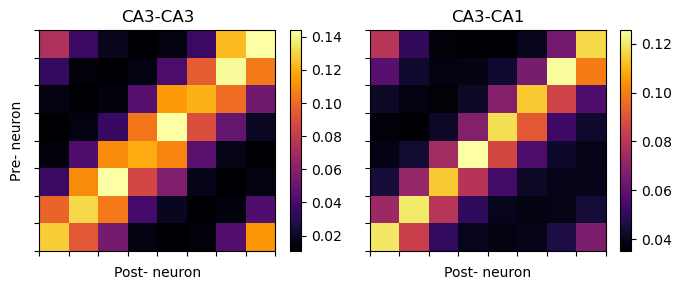

In [5]:
pop_per_unit = 1
n_pops = num_state_total * pop_per_unit
CA3_mean_wmx_arr = np.zeros((n_pops,n_pops,len(target_seed)))
CA1_mean_wmx_arr = np.zeros((n_pops,n_pops,len(target_seed)))
for seed in range(len(target_seed)):
    CA3_mean_wmx_arr[:,:,seed] = average_weight(CA3_weights[:,:,seed], n_pops, n_pops)
    CA1_mean_wmx_arr[:,:,seed] = average_weight(CA1_weights[:,:,seed], n_pops, n_pops)

CA3_mean_wmx = CA3_mean_wmx_arr.mean(-1)
CA1_mean_wmx = CA1_mean_wmx_arr.mean(-1)

fig, axs = plt.subplots(1,2,figsize=(7, 3)); plt.xlabel("Post- neuron")
fig, axs[0] = plot_heatmap(CA3_mean_wmx, fig=fig, ax=axs[0], title="CA3-CA3")
axs[0].set_xticks(np.linspace(0,n_pops,num_state_total+1)); axs[0].set_xticklabels([])
axs[0].set_yticks(np.linspace(0,n_pops,num_state_total+1)); axs[0].set_yticklabels([])
axs[0].set_ylabel("Pre- neuron"); axs[0].set_xlabel("Post- neuron")

fig, axs[1] = plot_heatmap(CA1_mean_wmx, fig=fig, ax=axs[1], title="CA3-CA1")
axs[1].set_xticks(np.linspace(0,n_pops,num_state_total+1)); axs[1].set_xticklabels([])
axs[1].set_yticks(np.linspace(0,n_pops,num_state_total+1)); axs[1].set_yticklabels([])
axs[1].set_xlabel("Post- neuron")

plt.tight_layout()

if save_plot: plt.savefig(os.path.join(plot_path,"avg_hippocampal_weights_lap_%d.png"%(load_lap)), dpi=300)
plt.show()

### Fig 2d, Plot center-aligned weights

In [51]:
unit_gran = 4; state_window = 4
target_state = np.arange(num_state_total)
n_units = unit_gran * len(target_state)        # 32 binned units per seed
half    = state_window * unit_gran             # center column index
n_seed  = len(target_seed)

CA3_aligned = np.zeros((n_units, state_window*len(target_state)+1, len(target_seed)))
CA1_aligned = np.zeros((n_units, state_window*len(target_state)+1, len(target_seed)))

CA3_sym_seed = np.zeros(n_seed)
CA1_sym_seed = np.zeros(n_seed)

for ii, seed in enumerate(target_seed):
    CA3_mean_wmx = average_weight(CA3_weights[:, :, ii], n_units, n_units)
    CA3_aligned[:,:,ii]  = extract_aligned_activity(
        CA3_mean_wmx, np.argmax(CA3_mean_wmx, axis=1), unit_gran*state_window)
    CA1_mean_wmx = average_weight(CA1_weights[:, :, ii], n_units, n_units)
    CA1_aligned[:,:,ii]  = extract_aligned_activity(
        CA1_mean_wmx, np.argmax(CA1_mean_wmx, axis=1), unit_gran*state_window)

    CA3_b = np.sum(CA3_aligned[:, :half+1]); CA3_a = np.sum(CA3_aligned[:, half:])
    CA1_b = np.sum(CA1_aligned[:, :half+1]); CA1_a = np.sum(CA1_aligned[:, half:])

    CA3_sym_seed[ii] = (CA3_b - CA3_a) / (CA3_b + CA3_a)
    CA1_sym_seed[ii] = (CA1_b - CA1_a) / (CA1_b + CA1_a)

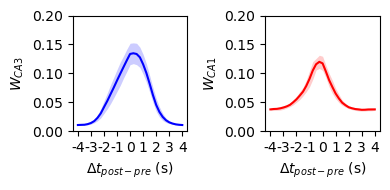

In [57]:
avg_CA3_aligned = CA3_aligned.mean(-1)
avg_CA1_aligned = CA1_aligned.mean(-1)

fig, axs = plt.subplots(1, 2, figsize=(4, 2))
axs[0] = plot_shaded(np.arange(avg_CA3_aligned.shape[1]),avg_CA3_aligned.mean(0),avg_CA3_aligned.std(0),axs[0],color='blue')
axs[0].set_xlabel(r"$\Delta t_{post-pre}$ (s)"); axs[0].set_xticks(np.arange(0, state_window*num_state_total+1, state_window))
axs[0].set_xticklabels(np.arange(0, num_state_total+1)-num_state_total//2)
axs[0].set_ylabel(r"$W_{CA3}$"); axs[0].set_ylim([0,0.2])

axs[1] = plot_shaded(np.arange(avg_CA1_aligned.shape[1]),avg_CA1_aligned.mean(0),avg_CA1_aligned.std(0),axs[1],color='red')
axs[1].set_xlabel(r"$\Delta t_{post-pre}$ (s)"); axs[1].set_xticks(np.arange(0, state_window*num_state_total+1, state_window))
axs[1].set_xticklabels(np.arange(0, num_state_total+1)-num_state_total//2)
axs[1].set_ylabel(r"$W_{CA1}$"); axs[1].set_ylim([0.0,0.2])

plt.tight_layout()

if save_plot: plt.savefig(os.path.join(plot_path,"total_CA1_PC_count.png"), dpi=300)
plt.show()

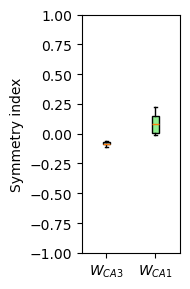

CA3 vs CA1 symmetry: p=0.000113, p_fdr=0.000113, d_z=-2.05, 95% CI [-0.22, -0.11]


In [8]:
# box plot
fig, ax = plt.subplots(1, 1, figsize=(2, 3))
plot_box(CA3_sym_seed, CA1_sym_seed, ax)
ax.set_xticklabels(['$W_{CA3}$', '$W_{CA1}$'])
ax.set_ylim([-1, 1]); ax.set_ylabel("Symmetry index")
plt.tight_layout()
if save_plot:
    plt.savefig(os.path.join(plot_path, "Weight_symmetry_box_lap_%d.png" % load_lap), dpi=300)
plt.show()

t_sym, p_sym = stats.ttest_rel(CA3_sym_seed, CA1_sym_seed)
_, p_fdr_sym, _, _ = multipletests([p_sym], method='fdr_bh')
d_sym = cohens_d_paired(CA3_sym_seed, CA1_sym_seed)
ci_lo, ci_hi = ci_paired(CA3_sym_seed, CA1_sym_seed)
print(f"CA3 vs CA1 symmetry: p={p_sym:.3g}, p_fdr={p_fdr_sym[0]:.3g}, "
      f"d_z={d_sym:.2f}, 95% CI [{ci_lo:.2f}, {ci_hi:.2f}]")

### Fig 2j, Spontaneous offline activity

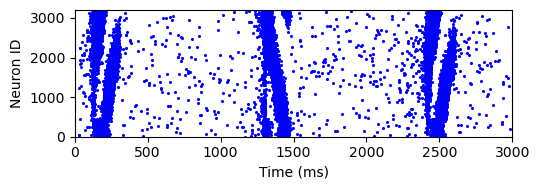

In [5]:
example_seed = target_seed[0]; load_lap = 5

CA3_place_fields = load_PF_starts()
CA3_place_cell_ID_list = generate_place_cell_ID_list(np.array(list(CA3_place_fields.keys()),dtype=int), np.array(list(CA3_place_fields.values())))
target_idx = reorder_neuron_idx(CA3_place_cell_ID_list,CA3_place_fields,np.arange(num_state_col))

ff = np.load(os.path.join(data_path,folder_root+str(example_seed),"CA3_replay_lap_%d.npz"%(load_lap)))
spike_times_CA3_PC = ff['spike_times_CA3_PC']; spiking_neurons_CA3_PC = ff['spiking_neurons_CA3_PC']; rate_CA3_PC = ff['rate_CA3_PC']
del ff

fig, ax = plt.subplots(1,1,figsize=(5.5,2))
plot_spike(spike_times_CA3_PC, spiking_neurons_CA3_PC, target_idx, zoom_to=rest_time, ax=ax)
ax.set_ylim([0, num_CA3_neurons])

fig.tight_layout()
if save_plot: plt.savefig(os.path.join(plot_path,"Spontaneous_activity_lap_%d.png"%(load_lap)), dpi=300)
plt.show()

In [9]:
replay, replay_results = analyse_replay(spike_times_CA3_PC, spiking_neurons_CA3_PC, rate_CA3_PC, verbose=True)
replay_time = list(replay_results.keys())[0]

Detecting replay: 100%|██████████| 3/3 [00:13<00:00,  4.53s/it]

Replay detected!


(array([86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]),)


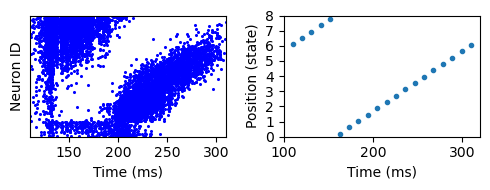

In [10]:
fig,axs = plt.subplots(1,2,figsize=(5,2))

plot_spike(spike_times_CA3_PC, spiking_neurons_CA3_PC, target_idx,
               zoom_from=replay_time[0], zoom_to=replay_time[1], ax=axs[0])
axs[0].set_ylim([0, num_CA3_neurons]); axs[0].set_yticks([]); axs[0].set_ylabel("Neuron ID")

path = replay_results[(replay_time[0], replay_time[1])]['fitted_path']
path[path<0] = unit_gran*num_state_total+path[path<0]
path[path>unit_gran*num_state_total] = path[path>unit_gran*num_state_total]-unit_gran*num_state_total
axs[1].plot(np.linspace(replay_time[0], replay_time[1], path.size), num_state_total*path/(4*num_state_total),'.')
axs[1].set_yticks(np.linspace(0,num_state_total,num_state_total+1))
axs[1].set_xlabel("Time (ms)")
print(np.where(replay_results[(replay_time[0], replay_time[1])]['shuffled_Rs']>replay_results[(replay_time[0], replay_time[1])]['R']))
axs[1].set_ylim([0, num_state_total]); axs[1].set_ylabel("Position (state)")

fig.tight_layout()
if save_plot: plt.savefig(os.path.join(plot_path,"Zoomed_in_replay_lap_%d.png"%(load_lap)), dpi=300)
plt.show()

### Fig 2i, Emergence of place cells

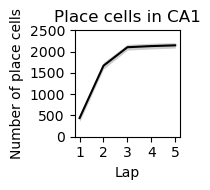

In [5]:
target_lap= np.arange(5)+1
PC_count = np.zeros((len(target_seed),len(target_lap)),dtype=int)
for ii,mm in enumerate(target_seed):
    foldername = folder_root+str(mm)
    for ee in range(len(target_lap)):
        CA1_place_fields = load_PF_starts(os.path.join(data_path, foldername, "detected_PC/CA1_lap_"+str(target_lap[ee])+".pkl"))
        PC_count[ii,ee] = len(CA1_place_fields)

fig, ax = plt.subplots(1, 1, figsize=(2, 2))
ax = plot_shaded(target_lap,PC_count.mean(0),PC_count.std(0),ax,color='black')
ax.set_xlabel("Lap"); ax.set_xticks(target_lap)
ax.set_yticks(np.linspace(0,2500,6))
ax.set_ylabel("Number of place cells")
ax.set_title("Place cells in CA1")
plt.tight_layout()

if save_plot: plt.savefig(os.path.join(plot_path,"total_CA1_PC_count.png"), dpi=300)
plt.show()

### Fig 2j, Simulated place cell activity

In [9]:
load_lap = 5
seed = target_seed[0]
foldername = folder_root + str(seed)

CA1_activity = np.load(os.path.join(data_path, foldername, "activity/CA1_activity_lap_"+str(load_lap)+".npz"))["CA1_activity"]
place_thr_FR = np.load(os.path.join(data_path, foldername, "activity/CA1_activity_lap_"+str(load_lap)+".npz"))["place_thr_FR"]
w_CA3_CA1 = CA1_mean_wmx_arr[:,:,load_lap-1]
CA1_PF = load_PF_starts(os.path.join(data_path, foldername, "detected_PC/CA1_lap_"+str(load_lap)+".pkl"))

place_field_sorted_idx = np.array(list(CA1_PF.keys()))
place_div_idx = np.hstack((place_field_sorted_idx,np.setdiff1d(np.arange(num_CA1_neurons),place_field_sorted_idx)))

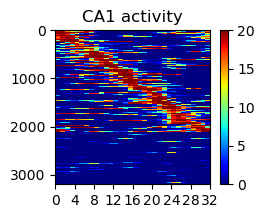

In [10]:
xlab = []

for ii in range(num_state_total):
    xlab.append("%d"%(ii))

data = CA1_activity[:, place_div_idx].T
x = np.arange(data.shape[1] + 1)
y = np.arange(data.shape[0] + 1)

#place_field_sorted_idx
fig, ax = plt.subplots(1, 1,figsize=(2.5, 2))
fig, ax = plot_heatmap(data, fig, ax, title="CA1 activity", cmap="jet", vmin=0, vmax=max_input_FR)
plt.gca().yaxis.set_inverted(True)
ax.set_xticks(np.linspace(0,int(data.shape[1]/num_state_total)*num_state_total,num_state_total+1))

if save_plot: plt.savefig(os.path.join(plot_path,"CA1_activity_lap_%d.png"%(load_lap)), dpi=300)
plt.show()

### Fig 2k, Averaged CA1 place field

In [34]:
act_window = 3

avg_PF    = np.zeros((len(target_seed), (2 * act_window + 1) * unit_gran))
gamma_app = np.zeros(len(target_seed))
gamma_ret = np.zeros(len(target_seed))

# distances = np.arange(1, act_window + 1, dtype=float)
distances = np.arange(1,(act_window + 1) * unit_gran, dtype=float)/unit_gran

for ii, seed in enumerate(target_seed):
    foldername = folder_root + str(seed)
    CA1_act = np.load(
        os.path.join(data_path, foldername, f"activity/CA1_activity_lap_{load_lap}.npz")
    )["CA1_activity"]  # shape: (num_state_total * unit_gran, num_CA1_neurons)
    CA1_PF_seed = load_PF_starts(
        os.path.join(data_path, foldername, f"detected_PC/CA1_lap_{load_lap}.pkl")
    )

    pf_profiles  = []
    gapp_list    = []
    gret_list    = []

    for nid, pos in CA1_PF_seed.items():
        nid_int    = int(nid)
        act = CA1_act[:, nid_int]
        peak_idx = np.argmax(act)
        act_extended = np.tile(act, 3)
        window = act_extended[peak_idx + len(act) - act_window * unit_gran: peak_idx + len(act) + (act_window + 1) * unit_gran]

        peak_val = window[act_window * unit_gran: (act_window + 1) * unit_gran].mean()
        if peak_val <= 0:
            continue
        profile = window
        pf_profiles.append(profile)

        # Fit gamma on this individual profile at state resolution
        app_vals   = window[act_window*unit_gran + 1:]
        ret_vals   = window[::-1][act_window*unit_gran + 1:]
        gapp_list.append(np.exp(np.polyfit(distances, np.log(np.maximum(app_vals, 1e-10)), 1)[0]))
        gret_list.append(np.exp(np.polyfit(distances, np.log(np.maximum(ret_vals, 1e-10)), 1)[0]))

    if pf_profiles:
        avg_PF[ii]    = np.mean(pf_profiles, axis=0)
        gamma_app[ii] = np.mean(gapp_list)
        gamma_ret[ii] = np.mean(gret_list)

print(f"avg_PF shape: {avg_PF.shape}")
print(f"gamma_app: {gamma_app.round(3)}")
print(f"gamma_ret: {gamma_ret.round(3)}")

avg_PF shape: (10, 28)
gamma_app: [0.405 0.401 0.41  0.369 0.429 0.393 0.415 0.435 0.427 0.385]
gamma_ret: [0.279 0.282 0.277 0.267 0.3   0.268 0.272 0.276 0.271 0.28 ]


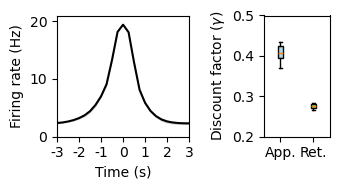

Approach vs. retreat (place field): p=4.988e-09, p_fdr=4.988e-09, d=6.768, 95% CI [0.1160, 0.1434]


In [33]:
# xx: unit_gran sub-steps per state; xticks mark the start of each state
xx = np.arange((2 * act_window + 1) * unit_gran) / unit_gran - act_window

fig, axs = plt.subplots(1, 2, width_ratios=(2, 1), figsize=(3.5, 2))
plot_shaded(xx, avg_PF.mean(0), avg_PF.std(0), axs[0])
axs[0].set_xlabel('Time (s)')
axs[0].set_xticks(np.arange(-act_window, act_window + 1))
axs[0].set_xticklabels(["-3", "-2", "-1", "0", "1", "2", "3"])
axs[0].set_xlim([-act_window, act_window])
axs[0].set_ylabel('Firing rate (Hz)')
axs[0].set_ylim([0, max_input_FR + 1])

plot_box(gamma_app, gamma_ret, axs[1])
axs[1].set_xticklabels(["App.", "Ret."])
axs[1].set_ylim([0.2, 0.5]); axs[1].set_yticks(np.linspace(0.2, 0.5, 4))
axs[1].set_ylabel("Discount factor ($\\gamma$)")

plt.tight_layout()
if save_plot: plt.savefig(os.path.join(plot_path, "Assymetric_place_field.png"), dpi=300)
plt.show()

_, p_pf = stats.ttest_rel(gamma_app, gamma_ret)
_, p_fdr_pf, _, _ = multipletests([p_pf], method='fdr_bh')
d_pf = cohens_d_paired(gamma_app, gamma_ret)
ci_pf_lo, ci_pf_hi = ci_paired(gamma_app, gamma_ret)
print(f"Approach vs. retreat (place field): p={p_pf:.4g}, p_fdr={p_fdr_pf[0]:.4g}, d={d_pf:.3f}, 95% CI [{ci_pf_lo:.4f}, {ci_pf_hi:.4f}]")

### Fig. 2m, Trained feature prediction layer weight

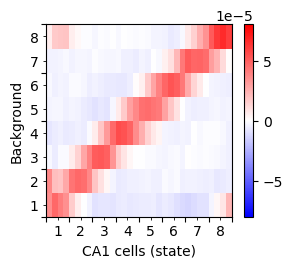

In [17]:
w_CA1_feat = np.zeros((num_CA1_neurons,num_features,len(target_seed)))

for ii, seed in enumerate(target_seed):
    foldername = folder_root + str(seed)
    w = np.load(os.path.join(data_path,foldername,"lap_%d.npz"%(load_lap)))["w_CA1_feat"]
    CA1_PF = load_PF_starts(os.path.join(data_path, foldername, "detected_PC/CA1_lap_"+str(load_lap)+".pkl"))
    CA1_place_cell_ID_list = generate_place_cell_ID_list(np.array(list(CA1_PF.keys()),dtype=int), np.array(list(CA1_PF.values())))
    CA1_target_idx = reorder_neuron_idx(CA1_place_cell_ID_list,CA1_PF,np.arange(num_state_total),include_cue=True)
    w_CA1_feat[:,:,ii] = w[CA1_target_idx,:]
    del CA1_PF, CA1_place_cell_ID_list

n_pops = num_state_total*unit_gran
mean_wmxs = np.zeros((n_pops, num_features, len(target_seed)))
for seed in target_seed:
    weightmx = w_CA1_feat[:,:,seed]
    mean_wmxs[:,:,seed] = average_weight(weightmx, num_features, n_pops)

mean_wmxs = mean_wmxs[:,2:,:] # exclude the first two features (reward and reward prediction error) to focus on the state representation
mmax = 8e-5

fig, ax = plt.subplots(1,1, figsize=(3, 2.5))
plot_heatmap(mean_wmxs.mean(-1).T, fig, ax, title="", vmin=-mmax, vmax=mmax, cmap="bwr")
ax.set_yticks(np.arange(num_features-2)+0.5, minor=True)
ax.set_yticklabels([]); ax.set_yticklabels(np.array(np.arange(num_features-2)+1,dtype=str), minor=True)

ax.set_xticks(np.arange(0,n_pops+1,unit_gran)); ax.set_xticklabels([])
ax.set_xticks(np.arange(unit_gran//2,n_pops-1,unit_gran), minor=True)
ax.set_xticklabels(np.array(np.arange(num_state_total)+1,dtype=str), minor=True)
ax.set_ylabel("Background"); ax.set_xlabel("CA1 cells (state)")

if save_plot: plt.savefig(os.path.join(plot_path,"feature_prediction_weight_lap_%d.png"%(load_lap)), dpi=300)
plt.show()

### Fig. 2n, Simulated background feature unit activity

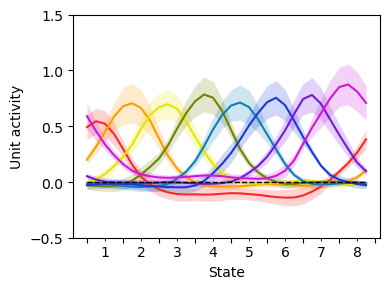

In [21]:
target_lap = np.arange(15)+1
feat_pred = np.zeros((num_features,unit_gran*num_state_total,len(target_lap),len(target_seed)))

for mm, seed in enumerate(target_seed):
    foldername = folder_root+str(seed)
    for ee, lap in enumerate(target_lap):
        w = np.load(os.path.join(data_path,foldername,"lap_%d.npz"%lap))["w_CA1_feat"]
        act = np.load(os.path.join(data_path,foldername,"activity/CA1_activity_lap_%d.npz"%lap))["CA1_activity"]
        prediction = (act@w).T
        feat_pred[:,:,ee,mm] = prediction

bg_linecolor = np.array([[255,39,39],[255,157,0],[230,230,0],[113,132,0],[15,127,183],[26,58,216],[119,25,219],[207,26,216]])/256
plot_Lap = 5

fig, ax = plt.subplots(1,1,figsize=(4,3))
xx = np.arange(feat_pred.shape[1])
Lap_pred = feat_pred[:,:,plot_Lap-1,:]

for bg in range(num_state_total):
    ax = plot_shaded(xx,Lap_pred[bg+2].mean(-1),Lap_pred[bg+2].std(-1),ax,list(bg_linecolor[bg]))
plt.hlines(0, color='k', linestyle='--', linewidth=1, xmin=0, xmax=feat_pred.shape[1]-1)

ax.set_ylim([-.5,1.5]); ax.set_yticks(np.arange(-0.5,1.6,0.5))
ax.set_xticks(np.linspace(0,feat_pred.shape[1],num_state_total+1))
ax.set_xticks(np.arange(0,n_pops+1,unit_gran)); ax.set_xticklabels([])
ax.set_xticks(np.arange(unit_gran//2,n_pops-1,unit_gran), minor=True)
ax.set_xticklabels(np.array(np.arange(num_state_total)+1,dtype=str), minor=True)
ax.set_ylabel("Unit activity"); ax.set_xlabel("State")

plt.tight_layout()

if save_plot: plt.savefig(os.path.join(plot_path,"background_unit_activity_lap_%d.png"%plot_episode), dpi=300)
plt.show()

In [22]:
act_window = int(4 * unit_gran)
distances = np.arange(act_window) / unit_gran

avg_pred  = np.zeros((len(target_seed), act_window * 2 + 1))
gamma_app = np.zeros(len(target_seed))
gamma_ret = np.zeros(len(target_seed))

p0     = [0.5, 0.1, 0]
bounds = ([0.1, 1e-6, -0.2], [20, 1-1e-9, 0.5])

for ii, mm in enumerate(target_seed):
    state_profiles = []
    gapp_list      = []
    gret_list      = []

    seed_pred = Lap_pred[:,:,mm]

    for ss in range(num_state_total):
        extended_pred = np.tile(seed_pred[ss+2], 3)
        peak_idx = np.argmax(seed_pred[ss+2])
        profile = extended_pred[peak_idx + unit_gran*num_state_total - act_window: peak_idx + unit_gran*num_state_total + act_window + 1]

        app_vals = profile[:act_window][::-1]  # increasing distance from peak
        ret_vals = profile[act_window + 1:]

        popt_app, _, _ = curve_fit_calc(distances, app_vals, exponential_func, p0=p0, bounds=bounds)
        popt_ret, _, _ = curve_fit_calc(distances,  ret_vals, exponential_func, p0=p0, bounds=bounds)

        state_profiles.append(profile)
        gapp_list.append(popt_app[1])  # gamma only
        gret_list.append(popt_ret[1])

    # if state_profiles:
    avg_pred[ii]  = np.mean(state_profiles, axis=0)
    gamma_app[ii] = np.mean(gapp_list)
    gamma_ret[ii] = np.mean(gret_list)


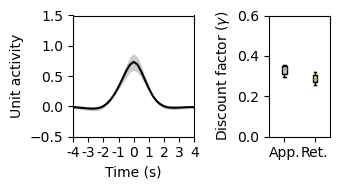

Approach vs. retreat (feature field): p=0.02541, p_fdr=0.02541, d=0.846, 95% CI [0.0054, 0.0650]


In [23]:
xx = np.arange((2 * act_window)+1) - act_window
xx = xx / unit_gran

fig, axs = plt.subplots(1, 2, width_ratios=(2, 1), figsize=(3.5, 2))
axs[0] = plot_shaded(xx, avg_pred.mean(0), avg_pred.std(0), axs[0])
axs[0].set_xlim([xx[0], xx[-1]])
axs[0].set_xticks(np.arange(xx[0], xx[-1]+1))
axs[0].set_xticklabels(np.array(np.arange(2*act_window//unit_gran+1)-act_window//unit_gran, dtype=str))
axs[0].set_xlabel("Time (s)")
axs[0].set_ylim([-.5, 1.5]); axs[0].set_yticks(np.arange(-0.5, 1.6, 0.5))
axs[0].set_ylabel("Unit activity")

plot_box(gamma_app, gamma_ret, axs[1])
axs[1].set_xticklabels(["App.", "Ret."])
axs[1].set_ylim([0.0, 0.6]); axs[1].set_yticks(np.linspace(0, 0.6, 4))
axs[1].set_ylabel("Discount factor ($\\gamma$)")

plt.tight_layout()
if save_plot: plt.savefig(os.path.join(plot_path, "Assymetric_feature_field.png"), dpi=300)
plt.show()

_, p_ff = stats.ttest_rel(gamma_app, gamma_ret)
_, p_fdr_ff, _, _ = multipletests([p_ff], method='fdr_bh')
d_ff = cohens_d_paired(gamma_app, gamma_ret)
ci_ff_lo, ci_ff_hi = ci_paired(gamma_app, gamma_ret)
print(f"Approach vs. retreat (feature field): p={p_ff:.4g}, p_fdr={p_fdr_ff[0]:.4g}, d={d_ff:.3f}, 95% CI [{ci_ff_lo:.4f}, {ci_ff_hi:.4f}]")

# Figure 3. Reward introduction

### Load

In [20]:
trajectory = np.arange(num_state_total)
feat_Lap = [np.arange(6,11),np.arange(11,16)]
feat_state = np.array([3,num_state_total-1])
feat_ID = 0
feat_speed = feature_speed[feat_ID]
feat_episode = [np.arange(6,11),np.arange(11,16)]

from plots import create_gradient
grad1 = create_gradient([.8,.5,.5], [.9,0,0], 6)
grad2 = create_gradient([68/256,136/256,246/256], [0,0,.8], 5)
colors = np.tile([0,0,0],(5,1)) 
colors = np.vstack((colors,grad1[:-1]))
colors = np.vstack((colors,grad2))

target_episode = np.arange(1,16)

windows_per_state = steps_per_unit*np.ones((len(target_episode),len(trajectory)),dtype=int)

for case in range(len(feat_state)):
    feat_episode_case = feat_episode[case]
    feat_state_case = feat_state[case]
    windows_per_state[np.intersect1d(target_episode,feat_episode_case)-1,trajectory==feat_state_case] = int(steps_per_unit/feat_speed)

windows_per_state = np.cumsum(windows_per_state,axis=1)
windows_per_state = np.hstack((np.zeros((len(target_episode),1),dtype=int),windows_per_state))

### Fig. 3c, Perceived salience

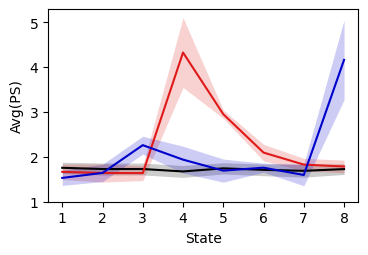

In [21]:
mean_PS = np.zeros((len(target_seed),len(target_episode),num_state_total))
max_PS = np.zeros((len(target_seed),len(target_episode),num_state_total))

for mm, seed in enumerate(target_seed):
    foldername = folder_root + str(seed)
    for ee, load_ep in enumerate(target_episode):
        PS_episode = np.load(os.path.join(data_path,foldername,"lap_%d.npz"%(load_ep)))["PS_list"]
        for ss in range(num_state_total):
            for idx in np.where(trajectory==ss)[0]:
                timeframe = np.arange(windows_per_state[ee,idx],windows_per_state[ee,idx+1])
                mean_PS[mm,ee,ss] = PS_episode[timeframe].mean()
                max_PS[mm,ee,ss] = np.max(PS_episode[timeframe])

fig, ax = plt.subplots(1, 1, figsize=(4,2.5))

xx = np.arange(num_state_total)+1

data_noRW = mean_PS[:,4,:].reshape(-1,num_state_total)
data_RW = mean_PS[:,5,:].reshape(-1,num_state_total)
data_rmv = mean_PS[:,10,:].reshape(-1,num_state_total)

ax = plot_shaded(xx,data_noRW.mean(0),data_noRW.std(0),ax,colors[4])
ax = plot_shaded(xx,data_RW.mean(0),data_RW.std(0),ax,colors[9])
ax = plot_shaded(xx,data_rmv.mean(0),data_rmv.std(0),ax,colors[14])
plt.yticks(np.arange(1,6)); plt.xticks(xx)
ax.set_ylabel("Avg(PS)"); ax.set_xlabel("State")

if save_plot: plt.savefig(os.path.join(plot_path,"Perceived_salience.png"), dpi=300)
plt.show()

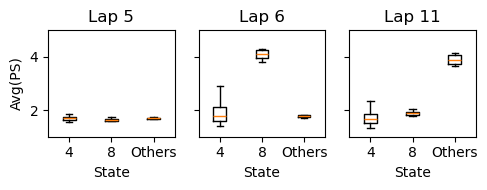

Before RW, state 4 vs. others: p=0.2685, p_fdr=0.3222, d=0.381, 95% CI [-0.0522, 0.1549]
Before RW, state 8 vs. others: p=0.9841, p_fdr=0.9841, d=-0.007, 95% CI [-0.0954, 0.0936]
After RW, state 4 vs. others: p=2.904e-19, p_fdr=8.713e-19, d=-4.265, 95% CI [-2.9502, -1.7617]
After RW, state 8 vs. others: p=0.2527, p_fdr=0.3222, d=0.394, 95% CI [0.0237, 0.3452]
After removal, state 4 vs. others: p=0.08029, p_fdr=0.1606, d=-0.606, 95% CI [-0.4250, 0.0425]
After removal, state 8 vs. others: p=2.409e-24, p_fdr=1.445e-23, d=-5.372, 95% CI [-3.0870, -1.7435]


In [22]:
fig, axs = plt.subplots(1,3,figsize=(5,2))

axs[0].boxplot([data_noRW[:,np.setdiff1d(np.arange(num_state_total),feat_state)].flatten(),data_noRW[:,feat_state[0]].flatten(),data_noRW[:,feat_state[1]].flatten()], showfliers=False)
axs[0].set_ylim([1,5]); axs[0].set_xticklabels(["4","8","Others"]); axs[0].set_xlabel("State")
axs[0].set_title("Lap 5"); axs[0].set_ylabel("Avg(PS)")

axs[1].boxplot([data_RW[:,np.setdiff1d(np.arange(num_state_total),feat_state)].flatten(),data_RW[:,feat_state[0]].flatten(),data_RW[:,feat_state[1]].flatten()], showfliers=False)
axs[1].set_ylim([1,5]); axs[1].set_yticklabels(""); axs[1].set_xticklabels(["4","8","Others"]); axs[1].set_xlabel("State")
axs[1].set_title("Lap 6")

axs[2].boxplot([data_rmv[:,np.setdiff1d(np.arange(num_state_total),feat_state)].flatten(),data_rmv[:,feat_state[0]].flatten(),data_rmv[:,feat_state[1]].flatten()], showfliers=False)
axs[2].set_ylim([1,5]); axs[2].set_yticklabels(""); axs[2].set_xticklabels(["4","8","Others"]); axs[2].set_xlabel("State")
axs[2].set_title("Lap 11")

plt.tight_layout()
plt.show()

# BH-FDR correction across all 6 comparisons
others_noRW = data_noRW[:,np.setdiff1d(np.arange(num_state_total),feat_state)].flatten()
others_RW   = data_RW[:,np.setdiff1d(np.arange(num_state_total),feat_state)].flatten()
others_rmv  = data_rmv[:,np.setdiff1d(np.arange(num_state_total),feat_state)].flatten()

ps_test_cases = [
    ("Before RW",    others_noRW, feat_state[0], data_noRW[:,feat_state[0]].flatten()),
    ("Before RW",    others_noRW, feat_state[1], data_noRW[:,feat_state[1]].flatten()),
    ("After RW",     others_RW,   feat_state[0], data_RW[:,feat_state[0]].flatten()),
    ("After RW",     others_RW,   feat_state[1], data_RW[:,feat_state[1]].flatten()),
    ("After removal",others_rmv,  feat_state[0], data_rmv[:,feat_state[0]].flatten()),
    ("After removal",others_rmv,  feat_state[1], data_rmv[:,feat_state[1]].flatten()),
]

ps_pvals = [stats.ttest_ind(x, y)[1] for label, x, fs, y in ps_test_cases]
_, ps_pfdr, _, _ = multipletests(ps_pvals, method='fdr_bh')

for (label, x, fs, y), p, p_q in zip(ps_test_cases, ps_pvals, ps_pfdr):
    d = cohens_d_ind(x, y)
    ci_lo, ci_hi = ci_ind(x, y)
    print(f"{label}, state {fs+1} vs. others: p={p:.4g}, p_fdr={p_q:.4g}, d={d:.3f}, 95% CI [{ci_lo:.4f}, {ci_hi:.4f}]")

### Fig. 3d, CA3 network evolvement

In [23]:
before_lap = 10; after_lap = 15

CA3_weights_before = np.zeros((num_CA3_neurons,num_CA3_neurons,len(target_seed)))
CA3_weights_after = np.zeros((num_CA3_neurons,num_CA3_neurons,len(target_seed)))

for ii, seed in enumerate(target_seed):
    foldername = folder_root + str(seed)
    
    ff = np.load(os.path.join(data_path,foldername,"lap_%d.npz"%(before_lap)))
    CA3_weights_before[:,:,ii] = ff["w_CA3_CA3"]
    del ff
    
    ff = np.load(os.path.join(data_path,foldername,"lap_%d.npz"%(after_lap)))
    CA3_weights_after[:,:,ii] = ff["w_CA3_CA3"]
    del ff

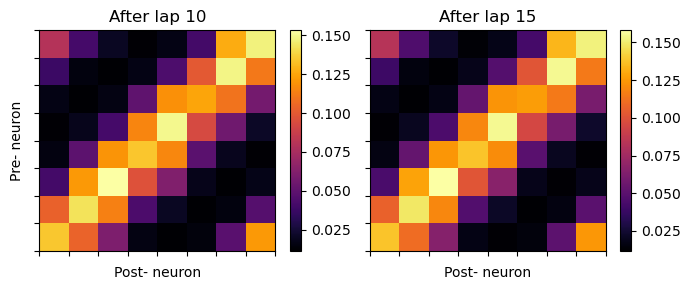

In [24]:
pop_per_unit = 1
n_pops = num_state_total * pop_per_unit
CA3_mean_before = np.zeros((n_pops,n_pops,len(target_seed)))
CA3_mean_after = np.zeros((n_pops,n_pops,len(target_seed)))
for seed in range(len(target_seed)):
    CA3_mean_before[:,:,seed] = average_weight(CA3_weights_before[:,:,seed], n_pops, n_pops)
    CA3_mean_after[:,:,seed] = average_weight(CA3_weights_after[:,:,seed], n_pops, n_pops)

fig, axs = plt.subplots(1,2,figsize=(7, 3)); plt.xlabel("Post- neuron")
fig, axs[0] = plot_heatmap(CA3_mean_before.mean(-1), fig=fig, ax=axs[0], title="After lap 10")
axs[0].set_xticks(np.linspace(0,n_pops,num_state_total+1)); axs[0].set_xticklabels([])
axs[0].set_yticks(np.linspace(0,n_pops,num_state_total+1)); axs[0].set_yticklabels([])
axs[0].set_ylabel("Pre- neuron"); axs[0].set_xlabel("Post- neuron")

fig, axs[1] = plot_heatmap(CA3_mean_after.mean(-1), fig=fig, ax=axs[1], title="After lap 15")
axs[1].set_xticks(np.linspace(0,n_pops,num_state_total+1)); axs[1].set_xticklabels([])
axs[1].set_yticks(np.linspace(0,n_pops,num_state_total+1)); axs[1].set_yticklabels([])
axs[1].set_xlabel("Post- neuron")

plt.tight_layout()

if save_plot: plt.savefig(os.path.join(plot_path,"CA3_weights_reward_relocation.png"), dpi=300)
plt.show()

### Fig. 3e, CA1 network evolvement

In [29]:
before_lap = 10; after_lap = 15

CA1_weights_before = np.zeros((num_CA1_neurons,num_CA1_neurons,len(target_seed)))
CA1_weights_after = np.zeros((num_CA1_neurons,num_CA1_neurons,len(target_seed)))

for ii, seed in enumerate(target_seed):
    foldername = folder_root + str(seed)
    
    ff = np.load(os.path.join(data_path,foldername,"lap_%d.npz"%(before_lap)))
    CA1_temp = ff["w_CA3_CA1"]
    del ff

    CA1_PF_before = load_PF_starts(os.path.join(data_path, foldername, "detected_PC/CA1_lap_"+str(before_lap)+".pkl"))
    place_field_sorted_idx = np.array(list(CA1_PF_before.keys()))
    place_cue_mix_idx = np.zeros(num_CA1_neurons)
    pp_idx = np.sort(np.random.choice(num_CA1_neurons, len(place_field_sorted_idx), replace=False))
    place_cue_mix_idx[pp_idx] = place_field_sorted_idx
    cue_cell_idx = np.setdiff1d(np.arange(num_CA1_neurons),place_field_sorted_idx)
    place_cue_mix_idx[np.setdiff1d(np.arange(num_CA1_neurons),pp_idx)] = cue_cell_idx
    place_cue_mix_idx = place_cue_mix_idx.astype(np.int32)
    del pp_idx

    CA1_weights_before[:,:,ii] = CA1_temp[:,place_cue_mix_idx]
    del CA1_temp, CA1_PF_before
        
    ff = np.load(os.path.join(data_path,foldername,"lap_%d.npz"%(after_lap)))
    CA1_temp = ff["w_CA3_CA1"]
    del ff

    CA1_PF_after = load_PF_starts(os.path.join(data_path, foldername, "detected_PC/CA1_lap_"+str(after_lap)+".pkl"))
    place_field_sorted_idx = np.array(list(CA1_PF_after.keys()))
    place_cue_mix_idx = np.zeros(num_CA1_neurons)
    pp_idx = np.sort(np.random.choice(num_CA1_neurons, len(place_field_sorted_idx), replace=False))
    place_cue_mix_idx[pp_idx] = place_field_sorted_idx
    cue_cell_idx = np.setdiff1d(np.arange(num_CA1_neurons),place_field_sorted_idx)
    place_cue_mix_idx[np.setdiff1d(np.arange(num_CA1_neurons),pp_idx)] = cue_cell_idx
    place_cue_mix_idx = place_cue_mix_idx.astype(np.int32)
    del pp_idx

    CA1_weights_after[:,:,ii] = CA1_temp[:,place_cue_mix_idx]
    del CA1_temp, CA1_PF_after


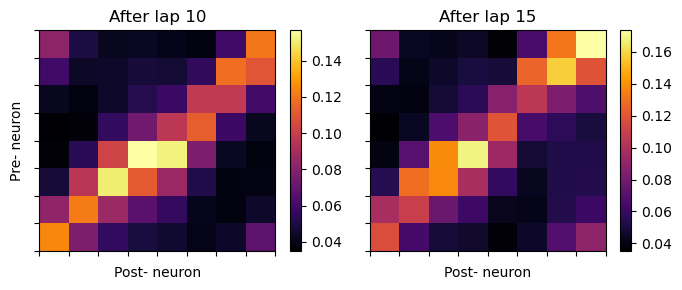

In [53]:
pop_per_unit = 1
n_pops = num_state_total * pop_per_unit
CA1_mean_before = np.zeros((n_pops,n_pops,len(target_seed)))
CA1_mean_after = np.zeros((n_pops,n_pops,len(target_seed)))
for seed in range(len(target_seed)):
    CA1_mean_before[:,:,seed] = average_weight(CA1_weights_before[:,:,seed], n_pops, n_pops)
    CA1_mean_after[:,:,seed] = average_weight(CA1_weights_after[:,:,seed], n_pops, n_pops)

fig, axs = plt.subplots(1,2,figsize=(7, 3)); plt.xlabel("Post- neuron")
fig, axs[0] = plot_heatmap(CA1_mean_before.mean(-1), fig=fig, ax=axs[0], title="After lap 10")
axs[0].set_xticks(np.linspace(0,n_pops,num_state_total+1)); axs[0].set_xticklabels([])
axs[0].set_yticks(np.linspace(0,n_pops,num_state_total+1)); axs[0].set_yticklabels([])
axs[0].set_ylabel("Pre- neuron"); axs[0].set_xlabel("Post- neuron")

fig, axs[1] = plot_heatmap(CA1_mean_after.mean(-1), fig=fig, ax=axs[1], title="After lap 15")
axs[1].set_xticks(np.linspace(0,n_pops,num_state_total+1)); axs[1].set_xticklabels([])
axs[1].set_yticks(np.linspace(0,n_pops,num_state_total+1)); axs[1].set_yticklabels([])
axs[1].set_xlabel("Post- neuron")

plt.tight_layout()

if save_plot: plt.savefig(os.path.join(plot_path,"CA1_weights_reward_relocation.png"), dpi=300)
plt.show()

In [87]:
target_lap_sim = np.arange(1, 16)
ca3_sim = np.zeros((len(target_seed), len(target_lap_sim)))
ca1_sim = np.zeros((len(target_seed), len(target_lap_sim)))

ca3_s4_overrep = np.zeros((len(target_seed), len(target_lap_rep)))
ca3_s8_overrep = np.zeros((len(target_seed), len(target_lap_rep)))
ca1_s4_overrep = np.zeros((len(target_seed), len(target_lap_rep)))
ca1_s8_overrep = np.zeros((len(target_seed), len(target_lap_rep)))

# cell_per_unit
for ii, seed in enumerate(target_seed):
    foldername = folder_root + str(seed)
    baseline_CA3 = np.load(
        os.path.join(data_path, foldername, "lap_5.npz")
    )["w_CA3_CA3"].flatten()
    bnCA3 = np.linalg.norm(baseline_CA3)

    baseline_CA1 = np.load(
        os.path.join(data_path, foldername, "lap_5.npz")
    )["w_CA3_CA1"].flatten()
    bnCA1 = np.linalg.norm(baseline_CA1)

    for ee, lap in enumerate(target_lap_sim):
        wCA3 = np.load(
            os.path.join(data_path, foldername, f"lap_{lap}.npz")
        )["w_CA3_CA3"]
        ca3_sim[ii, ee] = np.dot(baseline_CA3, wCA3.flatten()) / (bnCA3 * np.linalg.norm(wCA3.flatten()) + 1e-12)
        wCA1 = np.load(
            os.path.join(data_path, foldername, f"lap_{lap}.npz")
        )["w_CA3_CA1"]
        ca1_sim[ii, ee] = np.dot(baseline_CA1, wCA1.flatten()) / (bnCA1 * np.linalg.norm(wCA1.flatten()) + 1e-12)

        rw_w  = wCA3[feat_state[0] * cell_per_unit:(feat_state[0] + 1) * cell_per_unit, :]
        ca3_s4_overrep[ii, ee] = rw_w.mean() / (wCA3.mean() + 1e-12)
        rw_w  = wCA3[feat_state[1] * cell_per_unit:(feat_state[1] + 1) * cell_per_unit, :]
        ca3_s8_overrep[ii, ee] = rw_w.mean() / (wCA3.mean() + 1e-12)

        rw_w  = wCA1[feat_state[0] * cell_per_unit:(feat_state[0] + 1) * cell_per_unit, :]
        ca1_s4_overrep[ii, ee] = rw_w.mean() / (wCA1.mean() + 1e-12)
        rw_w  = wCA1[feat_state[1] * cell_per_unit:(feat_state[1] + 1) * cell_per_unit, :]
        ca1_s8_overrep[ii, ee] = rw_w.mean() / (wCA1.mean() + 1e-12)


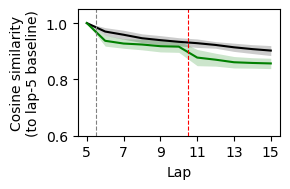

CA3 similarity (laps 10 vs 11): p=0.05373, p_fdr=0.05373, d=0.701, 95% CI [-0.0001, 0.0099]
CA1 similarity (laps 10 vs 11): p=2.072e-05, p_fdr=2.072e-05, d=2.551, 95% CI [0.0279, 0.0496]


In [117]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2))
plot_shaded(target_lap_sim[4:16], ca3_sim.mean(0)[4:16], ca3_sim.std(0)[4:16], ax, color='black')
plot_shaded(target_lap_sim[4:16], ca1_sim.mean(0)[4:16], ca1_sim.std(0)[4:16], ax, color='green')
ax.axvline(5.5,  color='gray', linestyle='--', linewidth=0.8)
ax.axvline(10.5, color='red',  linestyle='--', linewidth=0.8)
ax.set_xlabel("Lap")
ax.set_ylabel("Cosine similarity\n(to lap-5 baseline)")
ax.set_xticks(np.arange(5, 16, 2)); ax.set_ylim([0.6, 1.05])
plt.tight_layout()
if save_plot: plt.savefig(os.path.join(plot_path, "weight_stability.svg"), format='svg', bbox_inches='tight')
plt.show()

# Paired t-test: pre-relocation (lap 10) vs post-relocation (lap 11)
_, p_stab = stats.ttest_rel(ca3_sim[:, 9], ca3_sim[:, 10])
_, p_fdr_stab, _, _ = multipletests([p_stab], method='fdr_bh')
d_stab = cohens_d_paired(ca3_sim[:, 9], ca3_sim[:, 10])
ci_lo, ci_hi = ci_paired(ca3_sim[:, 9], ca3_sim[:, 10])
print(f"CA3 similarity (laps 10 vs 11): "
      f"p={p_stab:.4g}, p_fdr={p_fdr_stab[0]:.4g}, d={d_stab:.3f}, "
      f"95% CI [{ci_lo:.4f}, {ci_hi:.4f}]")

_, p_stab = stats.ttest_rel(ca1_sim[:, 9], ca1_sim[:, 10])
_, p_fdr_stab, _, _ = multipletests([p_stab], method='fdr_bh')
d_stab = cohens_d_paired(ca1_sim[:, 9], ca1_sim[:, 10])
ci_lo, ci_hi = ci_paired(ca1_sim[:, 9], ca1_sim[:, 10])
print(f"CA1 similarity (laps 10 vs 11): "
      f"p={p_stab:.4g}, p_fdr={p_fdr_stab[0]:.4g}, d={d_stab:.3f}, "
      f"95% CI [{ci_lo:.4f}, {ci_hi:.4f}]")

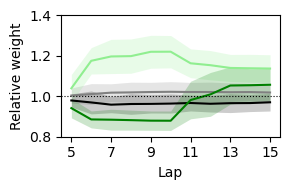

CA3 S4 over-rep (laps 10 vs 11): p=0.6122, p_fdr=0.6122, d=0.166, 95% CI [-0.0037, 0.0059]
CA3 S8 over-rep (laps 10 vs 11): p=0.7138, p_fdr=0.7138, d=-0.120, 95% CI [-0.0194, 0.0139]
CA1 S4 over-rep (laps 10 vs 11): p=5.337e-05, p_fdr=5.337e-05, d=2.263, 95% CI [0.0392, 0.0755]
CA1 S8 over-rep (laps 10 vs 11): p=0.008887, p_fdr=0.008887, d=-1.051, 95% CI [-0.1720, -0.0327]


In [118]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2))
plot_shaded(target_lap_rep[4:16], ca3_s4_overrep.mean(0)[4:16], ca3_s4_overrep.std(0)[4:16], ax, color='grey')
plot_shaded(target_lap_rep[4:16], ca3_s8_overrep.mean(0)[4:16], ca3_s8_overrep.std(0)[4:16], ax, color='black')
plot_shaded(target_lap_rep[4:16], ca1_s4_overrep.mean(0)[4:16], ca1_s4_overrep.std(0)[4:16], ax, color='lightgreen')
plot_shaded(target_lap_rep[4:16], ca1_s8_overrep.mean(0)[4:16], ca1_s8_overrep.std(0)[4:16], ax, color='green')

ax.axhline(1,    color='k',    linestyle=':',  linewidth=0.8)
ax.set_xlabel("Lap")
ax.set_ylabel("Relative weight")
ax.set_xticks(np.arange(5, 16, 2))
ax.set_yticks(np.arange(0.8, 1.5, 0.2))
plt.tight_layout()
if save_plot: plt.savefig(os.path.join(plot_path, "weight_overrep.svg"), dpi=300)
plt.show()

# Paired t-test: lap 10 vs lap 11
_, p_rep = stats.ttest_rel(ca3_s4_overrep[:,9], ca3_s4_overrep[:,10])
_, p_fdr_rep, _, _ = multipletests([p_rep], method='fdr_bh')
d_rep = cohens_d_paired(ca3_s4_overrep[:,9], ca3_s4_overrep[:,10])
ci_lo, ci_hi = ci_paired(ca3_s4_overrep[:,9], ca3_s4_overrep[:,10])
print(f"CA3 S4 over-rep (laps 10 vs 11): "
      f"p={p_rep:.4g}, p_fdr={p_fdr_rep[0]:.4g}, d={d_rep:.3f}, "
      f"95% CI [{ci_lo:.4f}, {ci_hi:.4f}]")

_, p_rep = stats.ttest_rel(ca3_s8_overrep[:,9], ca3_s8_overrep[:,10])
_, p_fdr_rep, _, _ = multipletests([p_rep], method='fdr_bh')
d_rep = cohens_d_paired(ca3_s8_overrep[:,9], ca3_s8_overrep[:,10])
ci_lo, ci_hi = ci_paired(ca3_s8_overrep[:,9], ca3_s8_overrep[:,10])
print(f"CA3 S8 over-rep (laps 10 vs 11): "
      f"p={p_rep:.4g}, p_fdr={p_fdr_rep[0]:.4g}, d={d_rep:.3f}, "
      f"95% CI [{ci_lo:.4f}, {ci_hi:.4f}]")

_, p_rep = stats.ttest_rel(ca1_s4_overrep[:,9], ca1_s4_overrep[:,10])
_, p_fdr_rep, _, _ = multipletests([p_rep], method='fdr_bh')
d_rep = cohens_d_paired(ca1_s4_overrep[:,9], ca1_s4_overrep[:,10])
ci_lo, ci_hi = ci_paired(ca1_s4_overrep[:,9], ca1_s4_overrep[:,10])
print(f"CA1 S4 over-rep (laps 10 vs 11): "
      f"p={p_rep:.4g}, p_fdr={p_fdr_rep[0]:.4g}, d={d_rep:.3f}, "
      f"95% CI [{ci_lo:.4f}, {ci_hi:.4f}]")

_, p_rep = stats.ttest_rel(ca1_s8_overrep[:,9], ca1_s8_overrep[:,10])
_, p_fdr_rep, _, _ = multipletests([p_rep], method='fdr_bh')
d_rep = cohens_d_paired(ca1_s8_overrep[:,9], ca1_s8_overrep[:,10])
ci_lo, ci_hi = ci_paired(ca1_s8_overrep[:,9], ca1_s8_overrep[:,10])
print(f"CA1 S8 over-rep (laps 10 vs 11): "
      f"p={p_rep:.4g}, p_fdr={p_fdr_rep[0]:.4g}, d={d_rep:.3f}, "
      f"95% CI [{ci_lo:.4f}, {ci_hi:.4f}]")

In [ ]:
target_lap_rep = np.arange(1, 16)
ca3_s4_overrep = np.zeros((len(target_seed), len(target_lap_rep)))
ca3_s8_overrep = np.zeros((len(target_seed), len(target_lap_rep)))
ca1_s4_overrep = np.zeros((len(target_seed), len(target_lap_rep)))
ca1_s8_overrep = np.zeros((len(target_seed), len(target_lap_rep)))
cpu = num_CA3_neurons // num_state_total  # CA3 cells per state

for ii, seed in enumerate(target_seed):
    foldername = folder_root + str(seed)
    for ee, lap in enumerate(target_lap_rep):
        w = np.load(
            os.path.join(data_path, foldername, f"lap_{lap}.npz")
        )["w_CA3_CA1"]  # shape: (num_CA3, num_CA1)
        rw_ss = feat_state[0] if lap <= feat_Lap[0][-1] else feat_state[1]
        rw_w  = w[rw_ss * cpu:(rw_ss + 1) * cpu, :]
        all_mean = w.mean()
        ca1_s4_overrep[ii, ee] = rw_w.mean() / (all_mean + 1e-12)


### Fig. 3f, Simulated activity before and after the reward relocation

In [38]:
seed = target_seed[5]
foldername = folder_root + str(seed)
place_thr_FR = np.load(os.path.join(data_path, foldername, "activity/CA1_activity_lap_"+str(before_lap)+".npz"))["place_thr_FR"]

CA1_activity_before = np.load(os.path.join(data_path, foldername, "activity/CA1_activity_lap_"+str(before_lap)+".npz"))["CA1_activity"]
CA1_PF_before = load_PF_starts(os.path.join(data_path, foldername, "detected_PC/CA1_lap_"+str(before_lap)+".pkl"))
place_div_idx_before = np.hstack((np.array(list(CA1_PF_before.keys())),np.setdiff1d(np.arange(num_CA1_neurons),np.array(list(CA1_PF_before.keys())))))

CA1_activity_after = np.load(os.path.join(data_path, foldername, "activity/CA1_activity_lap_"+str(after_lap)+".npz"))["CA1_activity"]
CA1_PF_after = load_PF_starts(os.path.join(data_path, foldername, "detected_PC/CA1_lap_"+str(after_lap)+".pkl"))
place_div_idx_after = np.hstack((np.array(list(CA1_PF_after.keys())),np.setdiff1d(np.arange(num_CA1_neurons),np.array(list(CA1_PF_after.keys())))))

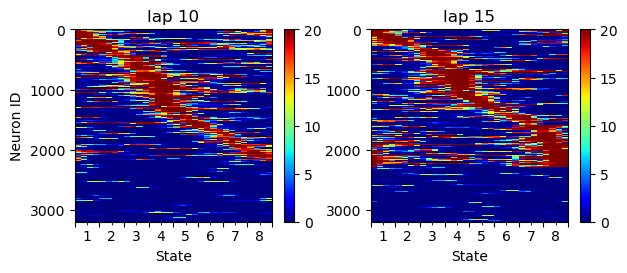

In [39]:
fig, axs = plt.subplots(1, 2,figsize=(7, 2.5))

data_before = CA1_activity_before[:,place_div_idx_before].T
plot_heatmap(data_before, fig, axs[0], title="lap %d"%(before_lap), vmin=0, vmax=max_input_FR, cmap='jet')
axs[0].invert_yaxis()
x_ticks = np.linspace(0,int(unit_gran)*num_state_total,num_state_total+1)
axs[0].set_xticks(x_ticks); axs[0].set_xticklabels([])
axs[0].set_xticks(x_ticks[:-1]+unit_gran/2, minor=True)
axs[0].set_xticklabels(np.array(np.arange(num_state_total)+1,dtype=str), minor=True)
axs[0].set_ylabel("Neuron ID"); axs[0].set_xlabel("State")

data_after = CA1_activity_after[:,place_div_idx_after].T
plot_heatmap(data_after, fig, axs[1], title="lap %d"%(after_lap), vmin=0, vmax=max_input_FR, cmap='jet')
axs[1].invert_yaxis()
axs[1].set_xticks(x_ticks); axs[1].set_xticklabels([])
axs[1].set_xticks(x_ticks[:-1]+unit_gran/2, minor=True)
axs[1].set_xticklabels(np.array(np.arange(num_state_total)+1,dtype=str), minor=True)
axs[1].set_xlabel("State")

if save_plot: plt.savefig(os.path.join(plot_path,"CA1_activity_reward_relocation.png"), dpi=300)
plt.show()

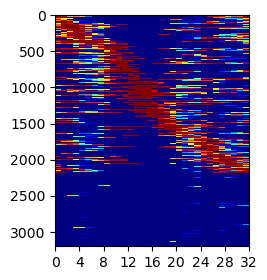

In [ ]:
act_thr = 3.5
pop_act = CA1_activity_before.mean(-1)
thr_idx = np.where(pop_act>act_thr)[0]

inhibited_CA1_activity = np.copy(CA1_activity_before)

for ii in thr_idx:
    data = CA1_activity_before[ii]
    sort_idx = np.argsort(data); sort_idx = sort_idx[::-1] # Descending order
    temp_sum = np.cumsum(data[sort_idx])/data.size
    data[sort_idx[np.where(temp_sum>=act_thr)[0][0]:]] = 0
    inhibited_CA1_activity[ii] = data
xlab = []

for ii in range(num_state_total):
    xlab.append("%d"%(ii))

data = inhibited_CA1_activity[:, place_div_idx_before].T
# Create meshgrid for pcolormesh
x = np.arange(data.shape[1] + 1)
y = np.arange(data.shape[0] + 1)

plt.figure(figsize=(2.5, 3))
plt.pcolormesh(x, y, data, cmap='jet', shading='auto',vmin=0,vmax=max_input_FR)  # shading='auto' avoids shape mismatch

plt.gca().yaxis.set_inverted(True)
plt.xticks(np.linspace(0,int(data.shape[1]/num_state_total)*num_state_total,num_state_total+1))
plt.show()

# plt.savefig(os.path.join(plotPath,"CA1_placefields_episode_"+str(load_episode)+".svg"), format="svg")

In [57]:
act_thr = 3.5
act_window = int(3 * unit_gran)

def inhibit_overactive_positions(activity_array, act_thr):
    """At positions where population activity exceeds `act_thr`, zero out the
    least-active neurons until the remaining activity falls back under `act_thr`
    (mimics lateral inhibition)."""
    inhibited = copy.deepcopy(activity_array)
    overactive_pos = np.where(inhibited.mean(-1) > act_thr)[0]
    for pos in overactive_pos:
        data = inhibited[pos]
        sort_idx = np.argsort(data)[::-1]
        cum_activity = np.cumsum(data[sort_idx]) / data.size
        cutoff = np.where(cum_activity >= act_thr)[0][0]
        data[sort_idx[cutoff:]] = 0
    return inhibited

def get_rw_nrw_activity(activity_array, place_thr_FR, unit_gran, act_window):
    """Split place cells into reward-zone (state index 3) vs. non-reward cells
    and average their peak-aligned activity profiles."""
    place_cell_idx = np.where(np.max(activity_array, axis=0) >= place_thr_FR)[0]
    peak_idx = find_PF_peak(activity_array)

    rw_idx = np.intersect1d(place_cell_idx, np.where((peak_idx >= 3 * unit_gran) & (peak_idx < 4 * unit_gran))[0])
    nrw_idx = np.setdiff1d(place_cell_idx, rw_idx)

    rw_activity = extract_aligned_activity(activity_array[:, rw_idx], peak_idx[rw_idx], act_window).mean(0)
    nrw_activity = extract_aligned_activity(activity_array[:, nrw_idx], peak_idx[nrw_idx], act_window).mean(0)
    return rw_activity, nrw_activity

rw_act = np.zeros((2, len(target_seed), 2 * act_window + 1))
nrw_act = np.zeros((2, len(target_seed), 2 * act_window + 1))

for ss, seed in enumerate(target_seed):
    foldername = folder_root + str(seed)
    activity_file = np.load(os.path.join(data_path, foldername, "activity/CA1_activity_lap_" + str(before_lap) + ".npz"))
    CA1_activity_array = activity_file["CA1_activity"]
    place_thr_FR = activity_file["place_thr_FR"]

    rw_act[0, ss], nrw_act[0, ss] = get_rw_nrw_activity(CA1_activity_array, place_thr_FR, unit_gran, act_window)

    inhibited_CA1_act = inhibit_overactive_positions(CA1_activity_array, act_thr)
    rw_act[1, ss], nrw_act[1, ss] = get_rw_nrw_activity(inhibited_CA1_act, place_thr_FR, unit_gran, act_window)

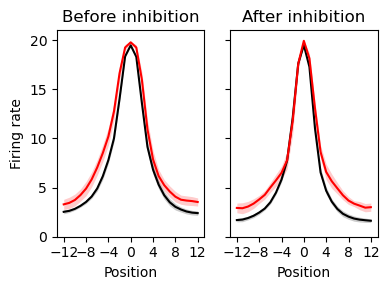

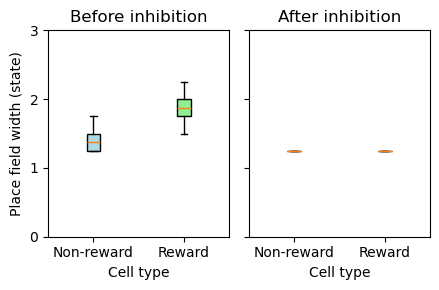

Before inhibition, reward vs. non-reward PF width: p=0.0001924, p_fdr=0.0003847, d=-1.911, 95% CI [-2.6114, -1.1886]
After inhibition, reward vs. non-reward PF width: p=1, p_fdr=1, d=0.000, 95% CI [-0.3372, 0.3372]


In [68]:
data_rw_bf, std_rw_bf = rw_act[0].mean(0), rw_act[0].std(0)
data_nrw_bf, std_nrw_bf = nrw_act[0].mean(0), nrw_act[0].std(0)
data_rw_af, std_rw_af = rw_act[1].mean(0), rw_act[1].std(0)
data_nrw_af, std_nrw_af = nrw_act[1].mean(0), nrw_act[1].std(0)

xx = np.arange(-act_window, act_window + 1)
xticks = np.linspace(-act_window, act_window, 2 * act_window // unit_gran + 1)

fig, axs = plt.subplots(1, 2, figsize=(4, 3), sharey=True)
plot_shaded(xx, data_nrw_bf, std_nrw_bf, ax=axs[0], color='black')
plot_shaded(xx, data_rw_bf, std_rw_bf, ax=axs[0], color='red')
plot_shaded(xx, data_nrw_af, std_nrw_af, ax=axs[1], color='black')
plot_shaded(xx, data_rw_af, std_rw_af, ax=axs[1], color='red')

for ax, title in zip(axs, ["Before inhibition", "After inhibition"]):
    ax.set_title(title)
    ax.set_xlabel("Position")
    ax.set_xticks(xticks)
    ax.set_ylim([0, max_input_FR + 1])
axs[0].set_ylabel("Firing rate")
plt.tight_layout()
if save_plot: plt.savefig(os.path.join(plot_path, "linear_reward_Placefield_rw_nrw.svg"), format="svg")
plt.show()

# Place-field width: number of consecutive above-threshold bins spanning the peak
width_thr = 10
mid = act_window

def pf_width(activity, thr, mid):
    right = np.where(activity[mid:] < thr)[0]
    left = np.where(activity[:mid][::-1] < thr)[0]
    right_edge = right[0] if right.size else mid
    left_edge = left[0] if left.size else mid
    return right_edge + left_edge

rw_PF_width_bf = [pf_width(rw_act[0, ss], width_thr, mid) for ss in range(len(target_seed))]
rw_PF_width_af = [pf_width(rw_act[1, ss], width_thr, mid) for ss in range(len(target_seed))]
nrw_PF_width_bf = [pf_width(nrw_act[0, ss], width_thr, mid) for ss in range(len(target_seed))]
nrw_PF_width_af = [pf_width(nrw_act[1, ss], width_thr, mid) for ss in range(len(target_seed))]

fig, axs = plt.subplots(1, 2, figsize=(4.5, 3), sharey=True)
plot_box(nrw_PF_width_bf, rw_PF_width_bf, axs[0])
plot_box(nrw_PF_width_af, rw_PF_width_af, axs[1])

y_max = max(rw_PF_width_bf + nrw_PF_width_bf + rw_PF_width_af + nrw_PF_width_af)
y_ticks = np.arange(0, y_max + unit_gran, unit_gran)
for ax, title in zip(axs, ["Before inhibition", "After inhibition"]):
    ax.set_title(title)
    ax.set_xlabel("Cell type")
    ax.set_xticklabels(["Non-reward", "Reward"])
    ax.set_yticks(y_ticks)
axs[0].set_ylabel("Place field width (state)"); axs[0].set_yticklabels(y_ticks//unit_gran)
plt.tight_layout()
if save_plot: plt.savefig(os.path.join(plot_path, "linear_reward_PFwidth_rw_nrw.svg"), format="svg")
plt.show()

# Paired t-tests (reward vs. non-reward place-field width), FDR-corrected across before/after inhibition
_, p_bf = stats.ttest_rel(rw_PF_width_bf, nrw_PF_width_bf)
_, p_af = stats.ttest_rel(rw_PF_width_af, nrw_PF_width_af)
_, p_fdr, _, _ = multipletests([p_bf, p_af], method='fdr_bh')

pf_test_cases = [
    ("Before inhibition", nrw_PF_width_bf, rw_PF_width_bf),
    ("After inhibition", nrw_PF_width_af, rw_PF_width_af),
]
for (label, rw_width, nrw_width), p, p_q in zip(pf_test_cases, [p_bf, p_af], p_fdr):
    d = cohens_d_paired(rw_width, nrw_width)
    ci_lo, ci_hi = ci_paired(rw_width, nrw_width)
    print(f"{label}, reward vs. non-reward PF width: p={p:.4g}, p_fdr={p_q:.4g}, "
          f"d={d:.3f}, 95% CI [{ci_lo:.4f}, {ci_hi:.4f}]")

### Fig. 3g, Number of place cell distributed across states 

In [18]:
target_lap = [5, 10, 15]
PC_count = np.zeros((len(target_seed), len(target_lap), num_state_total))

for ii, seed in enumerate(target_seed):
    foldername = folder_root + str(seed)
    for ee, lap in enumerate(target_lap):
        CA1_PF = load_PF_starts(
            os.path.join(data_path, foldername, "detected_PC/CA1_lap_%d.pkl" % lap)
        )
        counts = np.zeros(num_state_total, dtype=int)
        for nid, pos in CA1_PF.items():
            state = int(pos[1])  # pos[1] = s + 0.5 → int gives state index
            if 0 <= state < num_state_total:
                counts[state] += 1
        total = counts.sum()
        if total > 0:
            PC_count[ii, ee, :] = counts / total  # fraction per state

print(f"PC_count shape: {PC_count.shape}")  # (n_trials, n_laps, n_states)
print(f"Laps: {target_lap}")
print(f"Mean fraction per state (lap 5): {PC_count[:,0,:].mean(0).round(3)}")

PC_count shape: (10, 3, 8)
Laps: [5, 10, 15]
Mean fraction per state (lap 5): [0.113 0.136 0.101 0.154 0.123 0.119 0.143 0.11 ]


In [20]:
# One-sample one-tailed t-tests: PC fraction > uniform (1/num_state_total) at reward states
mu0 = 1 / num_state_total
pc_test_cases = [
    ("Lap 5",  0, feat_state[0]), ("Lap 5",  0, feat_state[1]),
    ("Lap 10", 1, feat_state[0]), ("Lap 10", 1, feat_state[1]),
    ("Lap 15", 2, feat_state[0]), ("Lap 15", 2, feat_state[1]),
]

pc_pvals = [stats.ttest_1samp(PC_count[:, lap_idx, ss], mu0, alternative='greater')[1]
            for label, lap_idx, ss in pc_test_cases]
_, pc_pfdr, _, _ = multipletests(pc_pvals, method='fdr_bh')

prev_label = None
for (label, lap_idx, ss), p, p_q in zip(pc_test_cases, pc_pvals, pc_pfdr):
    if label != prev_label and prev_label is not None:
        print("-----")
    prev_label = label
    x = PC_count[:, lap_idx, ss]
    d = cohens_d_1samp(x, mu0)
    ci_lo, ci_hi = ci_1samp(x)
    print(f"{label}, state {ss+1} vs. uniform: p={p:.4g}, p_fdr={p_q:.4g}, "
          f"d={d:.3f}, 95% CI [{ci_lo:.4f}, {ci_hi:.4f}]")

Lap 5, state 4 vs. uniform: p=0.03691, p_fdr=0.05537, d=0.640, 95% CI [0.1216, 0.1859]
Lap 5, state 8 vs. uniform: p=0.9613, p_fdr=0.9978, d=-0.630, 95% CI [0.0932, 0.1270]
-----
Lap 10, state 4 vs. uniform: p=6.627e-05, p_fdr=0.0002531, d=2.009, 95% CI [0.2019, 0.2869]
Lap 10, state 8 vs. uniform: p=0.9978, p_fdr=0.9978, d=-1.194, 95% CI [0.0834, 0.1146]
-----
Lap 15, state 4 vs. uniform: p=0.0002063, p_fdr=0.0004126, d=1.719, 95% CI [0.1785, 0.2547]
Lap 15, state 8 vs. uniform: p=8.438e-05, p_fdr=0.0002531, d=1.945, 95% CI [0.1730, 0.2288]


### Fig. 3i, Reduction of feature prediction error

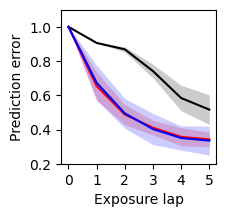

In [16]:
timestep = step_time_length//dA_granularity
error_arr = np.zeros((6,3,len(target_seed)))

for ii, seed in enumerate(target_seed):
    foldername = folder_root+str(seed)

    for ee in range(1,6):

        targ_feat = feat_state[0]

        ff = np.load(os.path.join(data_path,foldername,"lap_%d.npz"%ee))
        error_arr[ee,0,ii] = ff["error_list"][targ_feat*timestep:(targ_feat+1)*timestep+1,targ_feat+2].mean()
        del ff
            

        ff = np.load(os.path.join(data_path,foldername,"lap_%d.npz"%(ee+5)))
        error_arr[ee,1,ii] = ff["error_list"][targ_feat*timestep+1:(targ_feat+1)*timestep+1,feat_ID].mean()
        # error_arr[ee,1,ii] = np.abs(1-feat_pred[0,targ_feat*unit_gran:(targ_feat+1)*unit_gran,ee+4]).mean()
        # except: error_arr[ee,1,ii] = ff["error_list"][-timestep:,feat_ID].mean()
        del ff

        # ff = np.load(os.path.join(data_path,foldername,"lap_%d.npz"%(ee+10)))
        # error_arr[ee,2,ii] = np.abs(ff["error_list"][targ_feat*timestep+1,feat_ID]).mean()
        # # error_arr[ee,2,ii] = np.abs(feat_pred[0,targ_feat*unit_gran:(targ_feat+1)*unit_gran,ee+9]).mean()
        # del ff

        targ_feat = feat_state[1]
        ff = np.load(os.path.join(data_path,foldername,"lap_%d.npz"%(ee+10)))
        error_arr[ee,2,ii] = ff["error_list"][targ_feat*timestep+1:(targ_feat+1)*timestep+1,feat_ID].mean()
        # error_arr[ee,3,ii] = np.abs(1-feat_pred[0,targ_feat*unit_gran:(targ_feat+1)*unit_gran,ee+9]).mean()
        del ff

error_arr[0,:,:] = 1.0
fig, ax = plt.subplots(1,1,figsize=(2,2))
ax = plot_shaded(np.arange(6),error_arr.mean(-1)[:,0],error_arr.std(-1)[:,0],ax,color='black')
ax = plot_shaded(np.arange(6),error_arr.mean(-1)[:,1],error_arr.std(-1)[:,1],ax,color='red')
ax = plot_shaded(np.arange(6),error_arr.mean(-1)[:,2],error_arr.std(-1)[:,2],ax,color='blue')
# ax = plot_shaded(np.arange(6),error_arr.mean(-1)[:,3],error_arr.std(-1)[:,3],ax,color='green')

ax.set_xticks(np.arange(6)); ax.set_xlabel("Exposure lap")
ax.set_ylim([0.2,1.1]); ax.set_yticks(np.arange(1,6)/5); ax.set_ylabel("Prediction error")

if save_plot: plt.savefig(os.path.join(plot_path,"feat_learning_error.png"), dpi=300)
plt.show()

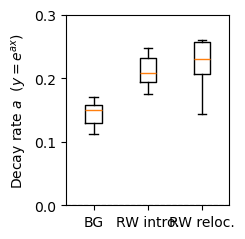

BG vs RW intro.: p=5.624e-05, p_fdr=8.436e-05, d=-2.247, 95% CI [-0.0947, -0.0490]
BG vs RW reloc.: p=2.644e-05, p_fdr=7.931e-05, d=-2.474, 95% CI [-0.1078, -0.0594]
RW intro. vs RW reloc.: p=0.4233, p_fdr=0.4233, d=-0.265, 95% CI [-0.0435, 0.0200]


In [48]:
# Fit y = exp(a*x) per seed per case; extract decay rate a
x_laps = np.arange(6, dtype=float)  # lap indices 0-5

a_vals = np.zeros((3, len(target_seed)))  # (cases, seeds)
for case in range(3):
    for ii in range(len(target_seed)):
        y = error_arr[::-1, case, ii]                          # shape (6,)
        log_y = np.log(np.maximum(y, 1e-10))
        a_vals[case, ii] = np.polyfit(x_laps, log_y, 1)[0]  # slope = a

# Box plot
fig, ax = plt.subplots(1, 1, figsize=(2.5, 2.5))
ax.boxplot([a_vals[0], a_vals[1], a_vals[2]], showfliers=False)
ax.set_xticklabels(["BG", "RW intro.", "RW reloc."])
ax.set_yticks(np.arange(0, 0.4, 0.1))
ax.set_ylabel("Decay rate $a$  ($y = e^{ax}$)")
ax.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.tight_layout()
if save_plot: plt.savefig(os.path.join(plot_path, "error_decay_rate.png"), dpi=300)
plt.show()

# Paired t-tests with Cohen's d and 95% CI
_, p_12 = stats.ttest_rel(a_vals[0], a_vals[1])
_, p_13 = stats.ttest_rel(a_vals[0], a_vals[2])
_, p_23 = stats.ttest_rel(a_vals[1], a_vals[2])
_, p_fdr, _, _ = multipletests([p_12, p_13, p_23], method='fdr_bh')

pair_indices = [(0, 1), (0, 2), (1, 2)]
pair_labels  = ["BG vs RW intro.", "BG vs RW reloc.", "RW intro. vs RW reloc."]
for label, p, pq, (i, j) in zip(pair_labels, [p_12, p_13, p_23], p_fdr, pair_indices):
    d = cohens_d_paired(a_vals[i], a_vals[j])
    ci_lo, ci_hi = ci_paired(a_vals[i], a_vals[j])
    print(f"{label}: p={p:.4g}, p_fdr={pq:.4g}, d={d:.3f}, 95% CI [{ci_lo:.4f}, {ci_hi:.4f}]")

### Fig. 3k, Reward unit activity before relocation

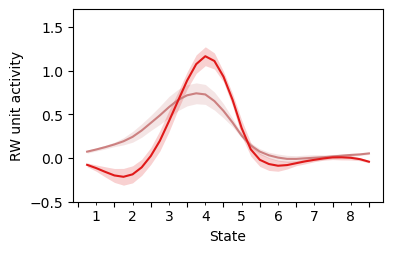

In [188]:
fig, ax = plt.subplots(1,1,figsize=(4,2.5))
for lap in [5,9]:
    plot_shaded(np.arange(num_state_total*unit_gran)+1,feat_pred[0,:,lap].mean(-1),feat_pred[0,:,lap].std(-1),ax,color=colors[lap])

ax.set_ylim([-.5,1.7])
x_ticks = np.linspace(0,int(unit_gran)*num_state_total,num_state_total+1)
ax.set_xticks(x_ticks); ax.set_xticklabels([])
ax.set_xticks(x_ticks[:-1]+unit_gran/2, minor=True)
ax.set_xticklabels(np.array(np.arange(num_state_total)+1,dtype=str), minor=True)
ax.set_ylabel("RW unit activity"); ax.set_xlabel("State")

if save_plot: plt.savefig(os.path.join(plot_path,"RW_activity_before_relocation.png"), dpi=300)
plt.show()

### Fig. 3l, Reward unit activity after relocation

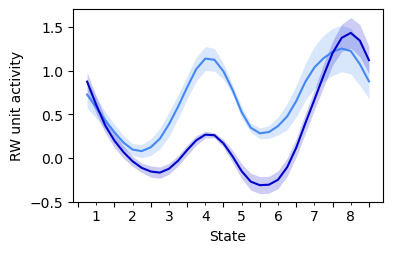

In [351]:
fig, ax = plt.subplots(1,1,figsize=(4,2.5))
for lap in [10,14]:
    plot_shaded(np.arange(num_state_total*unit_gran)+1,feat_pred[0,:,lap].mean(-1),feat_pred[0,:,lap].std(-1),ax,color=colors[lap])

ax.set_ylim([-.5,1.7])
x_ticks = np.linspace(0,int(unit_gran)*num_state_total,num_state_total+1)
ax.set_xticks(x_ticks); ax.set_xticklabels([])
ax.set_xticks(x_ticks[:-1]+unit_gran/2, minor=True)
ax.set_xticklabels(np.array(np.arange(num_state_total)+1,dtype=str), minor=True)
ax.set_ylabel("RW unit activity"); ax.set_xlabel("State")

if save_plot: plt.savefig(os.path.join(plot_path,"RW_activity_after_relocation.png"), dpi=300)
plt.show()